In [1]:
import os
import sys

from dotenv import load_dotenv

load_dotenv("../../.env")

# src 디렉토리를 Python path에 추가
sys.path.insert(0, os.path.abspath("../src"))

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

## Context Offloading: Filesystem

<img src="./assets/agent_header_files.png" width="800" style="display:block; margin-left:0;">

복잡한 작업 수행 중 에이전트 컨텍스트 창은 급격히 커질 수 있습니다. 평균적인 Manus 작업은 약 50회의 도구 호출을 사용하며, 이로 인해 상당한 양의 컨텍스트가 축적됩니다. 이러한 증가를 관리하는 강력한 기법은 파일 시스템 작업을 통한 **컨텍스트 오프로딩**입니다. 에이전트는 모든 도구 호출 관측값과 중간 결과를 컨텍스트 윈도우에 직접 저장하는 대신, 정보를 전략적으로 파일에 저장하고 [필요할 때 불러올](https://blog.langchain.com/context-engineering-for-agents/) 수 있습니다. 이를 통해 핵심 정보에 대한 접근성을 유지하면서도 작업에 집중할 수 있습니다.


이 접근 방식은 [Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) 및 [Hugging Face Open Deep Research](https://huggingface.co/blog/open-deep-research)와 같은 실제 운영 시스템에서 성공적으로 구현되었습니다. Anthropic의 [다중 에이전트 연구 시스템](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Subagent%20output%20to%20a%20filesystem%20to%20minimize%20the%20%E2%80%98game%20of%20telephone.% E2%80%99)는 또 다른 설득력 있는 예시를 제공합니다. 여기서 하위 에이전트는 자신의 작업을 외부 시스템에 저장하고 가벼운 참조 정보를 코디네이터에게 다시 전달합니다. 이는 여러 에이전트를 거치며 정보가 퇴색되는 “전화 게임” 효과를 방지하는 동시에, 새로운 하위 에이전트가 깨끗한 컨텍스트로 생성되도록 하고 필요할 때 메모리에서 연구 계획과 같은 저장된 컨텍스트를 검색할 수 있게 합니다.


에이전트가 토큰이 많은 컨텍스트를 샌드박스 환경의 파일에 기록함으로써, 메모리를 효율적으로 관리하면서도 필요할 때 상세한 정보를 검색할 수 있는 능력을 유지할 수 있습니다. 이 패턴은 일반적인 코디네이터를 통해 필터링하는 것보다 특화된 프롬프트가 더 나은 결과를 산출하는 코드, 보고서, 데이터 시각화와 같은 구조화된 출력물이나, 지속적인 관리 없이도 중간 결과를 보존해야 하는 장기 연구 작업에 특히 유용합니다.

### File Tools

본 구현은 LangGraph state 내에서 기존 파일 시스템을 모의(mock)하는 가상 파일 시스템 방식을 사용합니다. 핵심은 키가 모의 파일 경로를 나타내고 값이 파일 내용을 포함하는 간단한 딕셔너리를 활용하는 것입니다. 이 방식은 단일 에이전트 대화 내에서 컨텍스트를 유지하는 데 이상적인 단기적, 스레드 단위의 지속성을 제공하지만, 서로 다른 대화 스레드 간에 지속되어야 하는 정보에는 적합하지 않습니다. 파일 작업은 LangGraph의 `Command` 타입을 활용하여 에이전트 상태를 업데이트하므로, 도구가 가상 파일 시스템을 수정하고 에이전트 실행 전반에 걸쳐 적절한 상태 관리를 유지할 수 있습니다.

가상 파일 시스템에서 작동하는 세 가지 파일 도구—`ls`, `read_file`, `write_file`—를 구현하게 됩니다.

**Usage:** 
- LLM이 컨텍스트에 보존하고자 하는 정보가 있을 경우, `write_file`을 사용하여 이를 파일에 기록합니다. 이후 동일한 에이전트나 하위 에이전트가 `read_file`을 통해 해당 정보를 불러올 수 있습니다.
- 도구 호출을 통해 데이터를 파일에 기록하고, 도구 호출 반환 메시지에 파일 이름을 LLM에 제공할 수 있습니다. LLM은 나중에 해당 내용의 일부 또는 전부를 읽기로 결정하거나, 데이터를 처리하기 위해 다른 도구를 적용할 수 있습니다.
- `ls`를 사용하여 사용 가능한 파일 목록을 확인하십시오.

read/write 도구는 줄바꿈으로 구분된 일반 텍스트(`str.splitlines()`로 파싱된)를 입력으로 받습니다.


아래 프롬프트의 설명을 통해 각 도구의 작동 방식을 자세히 확인할 수 있습니다:

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
The <code>create_react_agent</code> was moved from the LangGraph library to the LangChain library and renamed to <code>create_agent</code> in the 1.0 code release post-filming. There are slight changes to the imports and code to accommodate this. The video may display the previous configuration.
</div>

In [3]:
from utils import show_prompt

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)

show_prompt(LS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  에이전트 state에 저장된 가상 파일 시스템의 모든 파일을 나열합니다.                                             │
│                                                                                                                 │
│  에이전트 memory에 현재 존재하는 파일을 표시합니다. 다른 파일 작업을 수행하기 전에 상황을 파악하고 파일 구조를  │
│  확인하는 데 이 기능을 사용하십시오.                                                                            │
│                                                                                                                 │
│  매개변수가 필요하지 않습니다. ls()를 호출하기만 하면 사용 가능한 모든 파일을 확인할 수 있습니다.               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
show_prompt(READ_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  가상 파일 시스템에 있는 파일의 내용을 선택적 페이지 단위로 읽습니다.                                           │
│                                                                                                                 │
│  이 도구는 줄 번호와 함께 파일 내용을 반환하며(`cat -n`과 유사), 컨텍스트 오버플로를 방지하기 위해 대용량       │
│  파일을 여러 조각으로 나누어 읽을 수 있습니다.                                                                  │
│                                                                                                                 │
│  매개변수:                                                                                                      │
│  - file_path (필수): 읽을 파일의 경로                                                                           │
│  - offset (선택 사항, 기본값=0): 읽기를 시작할 줄 번호                                                          │
│  - limit (선택 사항, 기본값=2000): 읽을 최대 줄 수                                                              │
│                                                                                                                 │
│  편집을 시작하기 전에 기존 내용을 파악하는 것은 필수적입니다. 파일을 편집하기 전에 항상 내용을 읽어보십시오.    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [5]:
show_prompt(WRITE_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  가상 파일 시스템에서 새 파일을 생성하거나 기존 파일을 완전히 덮어씁니다.                                       │
│                                                                                                                 │
│  이 도구는 새 파일을 생성하거나 파일 전체 내용을 덮어씁니다. 초기 파일 생성 또는 전체 재작성 시 사용하십시오.   │
│  파일은 에이전트 state에 영구적으로 저장됩니다.                                                                 │
│                                                                                                                 │
│  매개변수:                                                                                                      │
│  - file_path (required): 파일을 생성하거나 덮어쓸 경로                                                          │
│  - content (required): 파일에 기록할 전체 내용                                                                  │
│                                                                                                                 │
│  중요: 이 작업은 파일 전체 내용을 덮어씁니다.                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Let's implement these functions below. There are two items worth noting. The first is the use of `@tool(description=PROMPT)`. Note that when `description="xyz" is in the tool decorator, "xyz" is sent to the LLM and the docstring is suppressed. It is often more convenient to have lengthy descriptions in a separate prompts file. This provides space to explain both the operation of the tool and how it should be used in this application. The second item is the error messages. These messages are intended for the LLM vs a human user. In an agentic system, the LLM can use the information in error messages to retry the operation. 

In [6]:
%%writefile ../src/deep_agents_from_scratch/file_tools.py
"""Virtual file system tools for agent state management.

This module provides tools for managing a virtual filesystem stored in agent state,
enabling context offloading and information persistence across agent interactions.
"""

from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)
from deep_agents_from_scratch.state import DeepAgentState


@tool(description=LS_DESCRIPTION)
def ls(state: Annotated[DeepAgentState, InjectedState]) -> list[str]:
    """List all files in the virtual filesystem."""
    return list(state.get("files", {}).keys())


@tool(description=READ_FILE_DESCRIPTION, parse_docstring=True)
def read_file(
    file_path: str,
    state: Annotated[DeepAgentState, InjectedState],
    offset: int = 0,
    limit: int = 2000,
) -> str:
    """Read file content from virtual filesystem with optional offset and limit.

    Args:
        file_path: Path to the file to read
        state: Agent state containing virtual filesystem (injected in tool node)
        offset: Line number to start reading from (default: 0)
        limit: Maximum number of lines to read (default: 2000)

    Returns:
        Formatted file content with line numbers, or error message if file not found
    """
    files = state.get("files", {})
    if file_path not in files:
        return f"Error: File '{file_path}' not found"

    content = files[file_path]
    if not content:
        return "System reminder: File exists but has empty contents"

    lines = content.splitlines()
    start_idx = offset
    end_idx = min(start_idx + limit, len(lines))

    if start_idx >= len(lines):
        return f"Error: Line offset {offset} exceeds file length ({len(lines)} lines)"

    result_lines = []
    for i in range(start_idx, end_idx):
        line_content = lines[i][:2000]  # Truncate long lines
        result_lines.append(f"{i + 1:6d}\t{line_content}")

    return "\n".join(result_lines)


@tool(description=WRITE_FILE_DESCRIPTION, parse_docstring=True)
def write_file(
    file_path: str,
    content: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Write content to a file in the virtual filesystem.

    Args:
        file_path: Path where the file should be created/updated
        content: Content to write to the file
        state: Agent state containing virtual filesystem (injected in tool node)
        tool_call_id: Tool call identifier for message response (injected in tool node)

    Returns:
        Command to update agent state with new file content
    """
    files = state.get("files", {})
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(f"Updated file {file_path}", tool_call_id=tool_call_id)
            ],
        }
    )

Overwriting ../src/deep_agents_from_scratch/file_tools.py


# Revisiting state and reducer 
In the previous notebook, we defined the file state and reducer, but did not describe them. Let's do that here.
In `DeepAgentState`, `files` is defined as a dictionary with a key and value. As was mentioned above, the key is the filename and the value is the content of the file. `files` are added to state using the `file_reducer` when the `Command` in `write_files` is executed. In this reducer, `left` is the existing files in state and `right` is new values. The final statement allows the new values to overwrite old values: `{**left, **right}`, Python unpacks `left` first, then `right`. Any duplicate keys from `right` overwrite the earlier values from `left`.

```python
def file_reducer(left, right):
    """Merge two file dictionaries, with right side taking precedence.

    Used as a reducer function for the files field in agent state,
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side dictionary (existing files)
        right: Right side dictionary (new/updated files)

    Returns:
        Merged dictionary with right values overriding left values
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}


class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    - files: Virtual file system stored as dict mapping filenames to content
    """

    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]
```

We have a virtual filesystem and tools to work with it.  Let's build a simple research agent to try it out. 
The agent will store the user's request and then read it back before answering the user's question! 

Note that this simple approach is [very useful with long-running agent trajectories](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Long%2Dhorizon%20conversation,across%20extended%20interactions.)! In this simple example, all information is easily kept in context, but for long-running agents, context content can be compressed or eliminated. Storing information prior to compression and retrieving it when it's needed is smart context engineering.

In [7]:
# File usage instructions
FILE_USAGE_INSTRUCTIONS = """You have access to a virtual file system to help you retain and save context.                                  
                                                                                                                
## Workflow Process                                                                                            
1. **Orient**: Use ls() to see existing files before starting work                                             
2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     
3. **Read**: Once you are satisfied with the collected sources, read the saved file and use it to ensure that you directly answer the user's question."""

# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the user's question."""

# Full prompt
INSTRUCTIONS = (
    FILE_USAGE_INSTRUCTIONS + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_INSTRUCTIONS
)
show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Read**: Once you are satisfied with the collected sources, read the saved file and use it to ensure that  │
│  you directly answer the user's question.                                                                       │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer    │
│  the user's question.                                                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

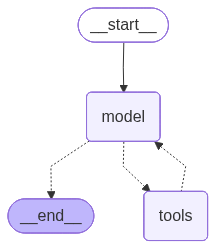

In [11]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import format_messages

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.state import DeepAgentState

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-20250514", temperature=0.0)
tools = [ls, read_file, write_file, web_search]

# Create agent with system prompt
agent = create_agent(
    model, tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Start the graph with no `files` in state and an user research request. 

In [12]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
        "files": {},
    }
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll help you get an overview of Model Context Protocol (MCP). Let me start by checking my current file system  │
│ and then search for information about MCP.                                                                      │
│                                                                                                                 │
│ 🔧 Tool Call: ls                                                                                                │
│    Args: {}                                                                                                     │
│    ID: toolu_01DaA1Rp9eGxspjKpxQhgCTs                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "user_request.txt",                                                                              │
│   "content": "User Request: Give me an overview of Model Context Protocol (MCP).\n\nThe user wants a            │
│ comprehensive overview of Model Context Protocol, including what it is, its purpose, key features, and how it   │
│ works."                                                                                                         │
│ }                                                                                                               │
│    ID: toolu_01BtmwgNVZ3YB3TZ5W5J3ykg                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file user_request.txt                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP overview what is it purpose features"                                    │
│ }                                                                                                               │
│    ID: toolu_01WRB59TTKxcQcDib59FVgXQ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ The Model Context Protocol (MCP) is an open standard protocol developed                                         │
│ by Anthropic to enable seamless integration between AI models and external systems like                         │
│ tools, databases, and other services. It acts as a standardized communication layer,                            │
│ allowing AI models to access and utilize data from various sources in a consistent and                          │
│ efficient manner. Essentially, MCP simplifies the process of connecting AI assistants                           │
│ to external services by providing a unified language for data exchange.                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "user_request.txt"                                                                               │
│ }                                                                                                               │
│    ID: toolu_01Fs6eeuuLsW7HkBRdxhdiT9                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  User Request: Give me an overview of Model Context Protocol (MCP).                                      │
│      2                                                                                                          │
│      3  The user wants a comprehensive overview of Model Context Protocol, including what it is, its purpose,   │
│ key features, and how it works.                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Based on my search, here's a comprehensive overview of Model Context Protocol (MCP):                            │
│                                                                                                                 │
│ ## What is Model Context Protocol (MCP)?                                                                        │
│                                                                                                                 │
│ Model Context Protocol (MCP) is an **open standard protocol** developed by Anthropic that serves as a           │
│ standardized communication layer between AI models and external systems. It's designed to enable seamless       │
│ integration and data exchange between AI assistants and various external services.                              │
│                                                                                                                 │
│ ## Key Purpose                                                                                                  │
│                                                                                                                 │
│ MCP addresses a fundamental challenge in AI development: **connecting AI models to external data sources and    │
│ tools**. Instead of building custom integrations for each service, MCP provides a unified framework that allows │
│ AI models to:                                                                                                   │
│                                                                                                                 │
│ - Access databases                                                                                              │
│ - Interact with APIs                                                                                            │
│ - Use external tools and services                                                                               │
│ - Retrieve information from various data sources                                                                │
│                                                                                                                 │
│ ## How It Works                                                                                                 │
│                                                                                                                 │
│ MCP acts as a **bridge or translation layer** that:                                                             │
│                                                                                                                 │
│ 1. **Standardizes Communication**: Provides a consistent language and protocol for data exchange                │
│ 2. **Simplifies Integration**: Eliminates the need for custom connectors for each external service              │
│ 3. **Enables Interoperability**: Allows different AI models to work with the same external systems using the    │
│ same protocol                                                                                                   │
│                                                                                                                 │
│ ## Key Benefits                                                                                                 │
│                                                                                                                 │
│ - **Consistency**: One protocol to rule them all - no need to learn different APIs for each service             │
│ - **Efficiency**: Streamlined data access and tool usage for AI models                                          │
│ - **Scalability**: Easy to add new services and tools without rebuilding integrations                           │
│ - **Open Standard**: Being open-source, it promotes wid

We can see the file saved in our mock file system. 

In [13]:
result["files"]

{'user_request.txt': 'User Request: Give me an overview of Model Context Protocol (MCP).\n\nThe user wants a comprehensive overview of Model Context Protocol, including what it is, its purpose, key features, and how it works.'}

Trace: 
https://smith.langchain.com/public/b03e20b4-e908-488d-84a9-8f891d17addd/r
<!-- https://smith.langchain.com/public/1066102f-d7b3-423c-b556-006865a1d479/r -->